# Classification des registres poétiques

Ce notebook aborde la classification automatique de deux registres poétiques à partir
d'indices lexicaux, morpho-syntaxiques et stylistiques. L'objectif dépasse la simple
prédiction d'étiquette : il s'agit de tester si certaines propriétés linguistiques
permettent de distinguer de manière stable deux régimes d'écriture poétique.

L'enjeu est double. D'une part, évaluer jusqu'où des modèles classiques et neuronaux
peuvent capturer des différences de registre c'est à dire des régularités qui ne sont
pas toujours de surface. D'autre part, interpréter les décisions de ces modèles à la
lumière d'hypothèses linguistiques précises, plutôt que de se contenter de métriques
agrégées.

Ce cadre place délibérément la linguistique au centre de l'analyse : les performances
des modèles n'ont d'intérêt que dans la mesure où elles éclairent ou contredisent 
ce que l'on sait du fonctionnement stylistique du langage poétique.

## Étape 1 — Question de recherche et hypothèses

### Question de recherche

Peut-on distinguer automatiquement les poèmes `romantique` et `tragique` dans
`PoetryFoundationData.csv` à partir des catégories grammaticales, de la ponctuation
expressive et de quelques indices lexicaux ? La cible est binaire :
$y \in \{\text{romantique}, \text{tragique}\}$.

Nous faisons l'hypothèse que le registre romantique contient davantage d'adjectifs
évaluatifs et de lexique affectif, tandis que le registre tragique présente plus de
négation, d'exclamations et d'interrogations, ainsi que de formes injonctives.

Cette question est non triviale car elle porte sur une variation de registre, et non
sur le vocabulaire seul. Elle serait falsifiée si les deux classes présentaient des
distributions linguistiques proches, ou si les performances des modèles restaient
proches du hasard.

### Variable cible

Le corpus brut contient de nombreux registres et thèmes poétiques (spirituel,
mythologie, guerre, amour, conflit, etc.). Pour cette étude, nous avons construit
une variable cible binaire $y \in \{\text{romantique}, \text{tragique}\}$ en filtrant
les poèmes annotés avec les mots-clés associés à ces deux registres. Cette restriction
permet une étude contrôlée et reproductible, tout en laissant les autres thèmes en
dehors du champ d'analyse.

### Observation attendue

On s'attend à observer des différences linguistiques systématiques entre les deux
registres, et une amélioration des performances lorsque le modèle parvient à capturer
des indices contextuels et morpho-syntaxiques au-delà du contenu lexical brut.

### Hypothèses linguistiques

1. Le registre romantique devrait présenter davantage d'adjectifs évaluatifs, de
   lexique affectif et de marqueurs subjectifs.
2. Le registre tragique devrait contenir plus d'expressions d'intensité, de négation,
   de ponctuation expressive, et potentiellement davantage de formes impératives ou
   exhortatives.
3. Les différences de registre ne devraient pas être entièrement capturées par un
   modèle lexical simple, car une partie de l'opposition dépend du contexte syntaxique
   et du style global du poème.
4. Un modèle Transformer devrait mieux capter ces indices contextuels qu'une régression
   logistique sur TF-IDF, en particulier lorsque les signaux stylistiques sont
   distribués sur l'ensemble du texte.

### Réflexions préliminaires

**Pourquoi est-ce non trivial ?**

La tâche ne se réduit pas à une distinction de vocabulaire, car les registres poétiques
peuvent partager des thèmes, des images et des champs lexicaux. L'information
discriminante est souvent diffuse, stylisée et dépendante de la combinaison entre
lexique, syntaxe et ponctuation, ce qui rend la classification plus difficile qu'elle
n'y paraît.

**Quel phénomène linguistique est impliqué ?**

Le phénomène central est la variation de registre, avec un intérêt particulier pour
les indices morpho-syntaxiques et stylistiques : adjectivation, modalisation,
ponctuation expressive, densité lexicale et usage éventuel de structures injonctives
ou exclamatives.

**Qu'est-ce qui falsifierait l'hypothèse ?**

L'hypothèse serait fragilisée si les deux registres présentaient des distributions
linguistiques quasi identiques, ou si les performances des modèles restaient proches
du hasard malgré une annotation fiable et un corpus suffisamment grand. Elle serait
également remise en cause si les indices supposés discriminants n'étaient pas corrélés
de manière stable avec les classes cibles.

## Étape 2 Données et prétraitement

Cette section charge le dataset `PoetryFoundationData.csv`, qui couvre un large spectre
de thèmes et de registres poétiques. Pour les besoins de cette expérience, on construit
un jeu binaire (`romantique` vs `tragique`) à partir de la colonne des tags, via un
filtrage explicite des mots-clés associés à chaque registre.

L'objectif est de garantir une expérimentation reproductible sur des données
authentiques, tout en assumant clairement que les autres registres ne sont pas
modélisés dans cette analyse. Les observations produites ici serviront de baseline
descriptive pour interpréter les résultats de classification dans les étapes suivantes.

In [100]:
import os
import re
import random
import importlib
import subprocess
import sys


def ensure_package(import_name, pip_name=None):
    try:
        importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
]:
    ensure_package(import_name, pip_name)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_PATH = "PoetryFoundationData.csv"


def load_poetry_dataset(path=DATA_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Le fichier {path} est introuvable. Place-le dans le meme dossier que le notebook."
        )

    raw_df = pd.read_csv(path)
    lower_cols = {c.lower(): c for c in raw_df.columns}

    required_cols = {"poem", "tags"}
    if not required_cols.issubset(set(lower_cols.keys())):
        raise ValueError(
            "Le dataset doit contenir les colonnes 'Poem' et 'Tags' pour construire les labels."
        )

    poem_col = lower_cols["poem"]
    tags_col = lower_cols["tags"]

    df_local = raw_df[[poem_col, tags_col]].rename(columns={poem_col: "text", tags_col: "tags"})
    df_local["text"] = df_local["text"].fillna("").astype(str).str.strip()
    df_local["tags"] = df_local["tags"].fillna("").astype(str)

    # Tableau de tous les themes avant filtrage binaire.
    all_themes = (
        df_local["tags"]
        .str.split(",")
        .explode()
        .astype(str)
        .str.strip()
        .str.lower()
    )
    all_themes = all_themes[all_themes != ""]
    themes_table = all_themes.value_counts().reset_index()
    themes_table.columns = ["theme", "count"]

    romantic_keywords = [
        "romantic", "love", "relationships", "nature", "beauty",
        "desire", "passion", "heart"
    ]
    tragic_keywords = [
        "tragic", "tragedy", "death", "sorrow", "grieving",
        "war", "conflict", "violence", "loss", "despair",
        "mourning", "ruin", "catastrophe"
    ]

    romantic_pattern = "|".join([re.escape(k) for k in romantic_keywords])
    tragic_pattern = "|".join([re.escape(k) for k in tragic_keywords])
    selected_theme_pattern = "|".join([re.escape(k) for k in (romantic_keywords + tragic_keywords)])

    themes_table["in_scope_romantic_or_tragic"] = themes_table["theme"].str.contains(
        selected_theme_pattern, regex=True
    )
    other_themes_table = themes_table[~themes_table["in_scope_romantic_or_tragic"]].copy()

    tags_lower = df_local["tags"].str.lower()
    romantic_mask = tags_lower.str.contains(romantic_pattern, regex=True)
    tragic_mask = tags_lower.str.contains(tragic_pattern, regex=True)

    initial_count = len(df_local)
    keep_mask = romantic_mask | tragic_mask
    kept_count = int(keep_mask.sum())

    # En cas de double match, on priorise "tragique" pour eviter une ambiguite optimiste.
    df_local = df_local.loc[keep_mask].copy()
    romantic_mask = romantic_mask.loc[df_local.index]
    tragic_mask = tragic_mask.loc[df_local.index]

    overlap_count = int((romantic_mask & tragic_mask).sum())

    df_local["label"] = np.where(tragic_mask, "tragique", "romantique")
    df_local = df_local[["text", "label"]]
    df_local = df_local[df_local["text"].str.len() > 0].dropna().reset_index(drop=True)

    final_count = len(df_local)
    excluded_count = initial_count - kept_count

    if final_count < 5000:
        raise ValueError(
            "Le filtrage actuel produit moins de 5000 textes. Ajuste les mots-cles de tags pour respecter la consigne."
        )

    stats = {
        "initial_count": initial_count,
        "kept_count": kept_count,
        "excluded_count": excluded_count,
        "overlap_count": overlap_count,
        "final_count": final_count
    }

    return df_local, stats, themes_table, other_themes_table


df, dataset_stats, themes_table, other_themes_table = load_poetry_dataset(DATA_PATH)
dataset_source = DATA_PATH

print(f"Source des donnees: {dataset_source}")
print(f"Poemes initiaux (apres nettoyage de base): {dataset_stats['initial_count']}")
print(f"Poemes gardes par le filtre romantique/tragique: {dataset_stats['kept_count']}")
print(f"Poemes exclus (autres themes): {dataset_stats['excluded_count']}")
print(f"Chevauchements romantique + tragique: {dataset_stats['overlap_count']}")
print(f"Nombre final d'instances: {dataset_stats['final_count']}")
print("Distribution des labels:")
print(df["label"].value_counts())

print("\nTop 20 themes (tous themes):")
display(themes_table.head(20))

print("\nTop 20 themes hors scope romantique/tragique:")
display(other_themes_table.head(20))

df.head()

Source des donnees: PoetryFoundationData.csv
Poemes initiaux (apres nettoyage de base): 13854
Poemes gardes par le filtre romantique/tragique: 8685
Poemes exclus (autres themes): 5169
Chevauchements romantique + tragique: 1591
Nombre final d'instances: 8669
Distribution des labels:
label
romantique    5666
tragique      3003
Name: count, dtype: int64

Top 20 themes (tous themes):


,theme,count,in_scope_romantic_or_tragic
0,living,6243,False
1,social commentaries,4302,False
2,relationships,3856,True
3,nature,3613,True
4,arts & sciences,3039,False
5,love,2126,True
6,activities,2107,False
7,death,1547,True
8,religion,1483,False
9,time & brevity,1468,False



Top 20 themes hors scope romantique/tragique:


,theme,count,in_scope_romantic_or_tragic
0,living,6243,False
1,social commentaries,4302,False
4,arts & sciences,3039,False
6,activities,2107,False
8,religion,1483,False
9,time & brevity,1468,False
10,history & politics,1456,False
11,family & ancestors,1345,False
12,the body,1336,False
13,life choices,1190,False


,text,label
0,Invisible fish swim this ghost ocean now descr...,romantique
1,"Hour in which I consider hydrangea, a salt or ...",romantique
2,"Of course wars, of course lice, of course limb...",tragique
3,This is the poem of death.\r\r\nThere is only ...,tragique
4,"Nothing can reach you now, not lead or steel,\...",tragique


### Découpage Train / Dev / Test

Le partitionnement en 80 % / 10 % / 10 % permet de réserver une partie du corpus à l’apprentissage, une autre à la sélection des paramètres et une dernière à l’évaluation finale. Le paramètre $random\_state = 42$ garantit la reproductibilité des expériences.

In [94]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=RANDOM_STATE
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print(f"Train: {len(train_df)}")
print(f"Dev:   {len(dev_df)}")
print(f"Test:  {len(test_df)}")
print("\nRépartition des classes dans l'ensemble d'entraînement :")
print(train_df["label"].value_counts(normalize=True).round(3))

Train: 6935
Dev:   867
Test:  867

Répartition des classes dans l'ensemble d'entraînement :
label
romantique    0.654
tragique      0.346
Name: proportion, dtype: float64


### Prétraitement comparatif

Deux variantes sont définies afin de comparer un traitement léger, qui conserve la ponctuation et minimise les transformations, à un traitement plus agressif, qui supprime les mots-outils et la ponctuation tout en réduisant les formes fléchies à leur lemme. Ce contraste est utile pour tester l’hypothèse selon laquelle certains indices stylistiques sont portés par la morphologie et la ponctuation autant que par le lexique.

In [95]:
import subprocess
import sys

try:
    import spacy
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "spacy"])
    import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
    nlp = spacy.load("en_core_web_sm")

light_token_pattern = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)

# tokenization simple, lemmatization
def preprocess_light(text):
    text = str(text).lower().strip()
    return light_token_pattern.findall(text)

# stemming
def preprocess_heavy(text):
    doc = nlp(str(text).lower())
    tokens = []
    for token in doc:
        if token.is_space or token.is_punct or token.is_stop:
            continue
        lemma = token.lemma_.strip().lower()
        if lemma and lemma != "-pron-":
            tokens.append(lemma)
    return tokens

print(preprocess_light("I have loved the night, and it sings with distant stars!"))
print(preprocess_heavy("I have loved the night, and it sings with distant stars!"))

['i', 'have', 'loved', 'the', 'night', ',', 'and', 'it', 'sings', 'with', 'distant', 'stars', '!']
['love', 'night', 'sing', 'distant', 'star']


### Analyse méthodologique, biais et considérations éthiques

**Source et domaine.**
Le corpus `PoetryFoundationData.csv` provient de Kaggle et regroupe des poèmes annotés
par thèmes éditoriaux. Le domaine correspond à la poésie littéraire, avec une forte
hétérogénéité diachronique, stylistique et socioculturelle.

**Biais potentiels.**
Plusieurs sources de biais méritent d'être signalées. Les thèmes sont attribués par
une taxonomie éditoriale qui ne recouvre pas parfaitement les registres linguistiques,
ce qui introduit un biais d'annotation. La représentation des poètes, périodes et
courants n'est pas uniforme, ce qui peut influencer la distribution lexicale. Le corpus
est par ailleurs majoritairement anglophone, alors que les labels projetés (`romantique`,
`tragique`) sont des catégories interprétatives qui ne se réduisent pas à une langue.
Enfin, la conversion des tags en classes binaires constitue une approximation et peut
introduire du bruit dans les étiquettes.

**Considérations éthiques.**
Il convient d'éviter de surinterpréter les prédictions comme des jugements de valeur
esthétique. Le modèle apprend des corrélations statistiques et non une compréhension
littéraire. La transformation des tags en labels est documentée explicitement pour
assurer la transparence et la reproductibilité de l'expérience.

**Justification des choix de prétraitement.**
Deux variantes sont comparées. La variante `preprocess_light` conserve la ponctuation
afin de préserver les marqueurs stylistiques (exclamation, suspension, interrogation),
qui constituent des signaux potentiellement discriminants en poésie. La variante
`preprocess_heavy` applique une lemmatisation avec suppression des stopwords et de la
ponctuation, pour tester l'information strictement lexico-sémantique en réduisant la
variance lexicale.

Les mots rares ne font pas l'objet d'un filtrage explicite à ce stade : leur effet est
évalué indirectement via le taux OOV et la taille du vocabulaire. Les emojis sont rares
dans la poésie canonique, ce qui fait de la ponctuation le principal signal
paralinguistique à préserver. La tokenisation en sous-mots n'est pas appliquée ici,
cette section visant les baselines de prétraitement ; elle sera traitée dans la partie
Transformer.

On compare ensuite les deux variantes sur la taille du vocabulaire, la longueur moyenne
et le taux OOV, puis sur une performance de classification obtenue avec une régression
logistique.

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# S'assure que le split existe meme si la cellule 7 n'a pas encore ete executee.
if "train_df" not in globals() or "dev_df" not in globals() or "test_df" not in globals():
    train_df, temp_df = train_test_split(
        df, test_size=0.20, stratify=df["label"], random_state=RANDOM_STATE
    )
    dev_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE
    )

# Sous-ensemble reproductible pour garder une execution rapide en notebook.
MAX_DOCS = 800
train_eval_df = train_df.sample(n=min(MAX_DOCS, len(train_df)), random_state=RANDOM_STATE)
dev_eval_df = dev_df.sample(n=min(MAX_DOCS, len(dev_df)), random_state=RANDOM_STATE)
test_eval_df = test_df.sample(n=min(MAX_DOCS, len(test_df)), random_state=RANDOM_STATE)


def preprocess_heavy_batch(texts):
    docs = nlp.pipe((str(t).lower() for t in texts), batch_size=64)
    output = []
    for doc in docs:
        tokens = []
        for token in doc:
            if token.is_space or token.is_punct or token.is_stop:
                continue
            lemma = token.lemma_.strip().lower()
            if lemma and lemma != "-pron-":
                tokens.append(lemma)
        output.append(tokens)
    return output


def tokenize_variant(df_split, variant_name):
    texts = df_split["text"].tolist()
    if variant_name == "light":
        return [preprocess_light(t) for t in texts]
    if variant_name == "heavy":
        return preprocess_heavy_batch(texts)
    raise ValueError(f"Variante inconnue: {variant_name}")


def compute_metrics_from_tokens(train_tokens, dev_tokens, test_tokens):
    vocab_train = set(tok for doc in train_tokens for tok in doc)
    vocab_dev = set(tok for doc in dev_tokens for tok in doc)
    vocab_test = set(tok for doc in test_tokens for tok in doc)

    avg_len_train = float(np.mean([len(doc) for doc in train_tokens]))
    avg_len_dev = float(np.mean([len(doc) for doc in dev_tokens]))
    avg_len_test = float(np.mean([len(doc) for doc in test_tokens]))

    dev_flat = [tok for doc in dev_tokens for tok in doc]
    oov_dev = sum(tok not in vocab_train for tok in dev_flat) / max(len(dev_flat), 1)

    test_flat = [tok for doc in test_tokens for tok in doc]
    oov_test = sum(tok not in vocab_train for tok in test_flat) / max(len(test_flat), 1)

    return {
        "vocab_train": len(vocab_train),
        "vocab_dev": len(vocab_dev),
        "vocab_test": len(vocab_test),
        "avg_len_train": avg_len_train,
        "avg_len_dev": avg_len_dev,
        "avg_len_test": avg_len_test,
        "oov_dev": oov_dev,
        "oov_test": oov_test,
    }


def train_eval_logreg_from_tokens(train_tokens, dev_tokens, y_train, y_dev):
    vectorizer = TfidfVectorizer(
        tokenizer=lambda x: x,
        preprocessor=lambda x: x,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
    )

    X_train = vectorizer.fit_transform(train_tokens)
    X_dev = vectorizer.transform(dev_tokens)

    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    pred_dev = clf.predict(X_dev)

    return {
        "accuracy_dev": accuracy_score(y_dev, pred_dev),
        "f1_macro_dev": f1_score(y_dev, pred_dev, average="macro"),
    }


rows = []
for variant_name in ["light", "heavy"]:
    print(f"Traitement de la variante: {variant_name}")
    train_tokens = tokenize_variant(train_eval_df, variant_name)
    dev_tokens = tokenize_variant(dev_eval_df, variant_name)
    test_tokens = tokenize_variant(test_eval_df, variant_name)

    m = compute_metrics_from_tokens(train_tokens, dev_tokens, test_tokens)
    p = train_eval_logreg_from_tokens(
        train_tokens,
        dev_tokens,
        train_eval_df["label"].tolist(),
        dev_eval_df["label"].tolist(),
    )

    rows.append({
        "variant": variant_name,
        "n_train_eval": len(train_eval_df),
        "n_dev_eval": len(dev_eval_df),
        "vocab_train": m["vocab_train"],
        "avg_len_train": m["avg_len_train"],
        "avg_len_dev": m["avg_len_dev"],
        "oov_dev": m["oov_dev"],
        "accuracy_dev": p["accuracy_dev"],
        "f1_macro_dev": p["f1_macro_dev"],
    })

comparison_df = pd.DataFrame(rows).sort_values("f1_macro_dev", ascending=False).reset_index(drop=True)
comparison_df

Traitement de la variante: light
Traitement de la variante: heavy


,variant,n_train_eval,n_dev_eval,vocab_train,avg_len_train,avg_len_dev,oov_dev,accuracy_dev,f1_macro_dev
0,heavy,800,800,17838,121.68375,121.6075,0.113418,0.68125,0.458643
1,light,800,800,21954,307.92875,304.6375,0.052739,0.67000,0.425331


### Interprétation des résultats de prétraitement

Le tableau `comparison_df` met en regard les deux variantes (`light` vs `heavy`) sur quatre dimensions :
taille du vocabulaire, longueur moyenne des séquences, taux OOV et performance en classification.

**Observations sur cet échantillon.**

La variante `heavy` obtient des scores légèrement supérieurs : accuracy de 0.6833 contre 0.6717
pour `light`, et F1-macro de 0.4557 contre 0.4378. L'écart reste modeste et sensible au split,
mais la tendance est cohérente.

Côté longueur, la suppression des stopwords et de la ponctuation réduit significativement
la taille des séquences (ex. train : 314.98 → 124.42 tokens en moyenne), ce qui allège
la représentation TF-IDF et réduit le bruit lexical.

En revanche, le taux OOV augmente avec `heavy` (0.1279 vs 0.0608), ce qui montre qu'une
normalisation agressive ne garantit pas une meilleure couverture du vocabulaire de test —
certains tokens informatifs disparaissent avec le filtrage.

**Ce que cela implique.**

Malgré un OOV plus élevé, `heavy` reste compétitif, ce qui suggère que la réduction du
bruit compense ici la perte de couverture lexicale. Cela répond directement à la question
posée en 2.3 : *"Does removing stopwords always help?"* — dans ce cas, oui, mais marginalement,
et au prix d'une représentation plus creuse.

Métriques utilisées :
$$Accuracy = \frac{TP + TN}{N} \qquad F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

**Conclusion (Section 2).** Le prétraitement `heavy` offre un léger avantage sur ce run.
La décision de preprocessing la plus impactante semble être la suppression des stopwords,
dont l'effet sur le vocabulaire est massif — même si son bénéfice en performance reste
dépendant du contexte et du modèle utilisé.

## Étape 3 Analyse Exploratoire et Linguistique

Cette section teste les hypothèses linguistiques avec des mesures interprétables: densité morpho-syntaxique ($ADJ$, $NOUN$, $VERB$), ponctuation expressive ($!$, $?$), et structure syntaxique via dépendances.

Objectif: vérifier si la distribution des catégories grammaticales, de la ponctuation expressive et de certains indices lexicaux différencie significativement les registres `romantique` et `tragique`.

Modele spaCy utilise: en_core_web_sm


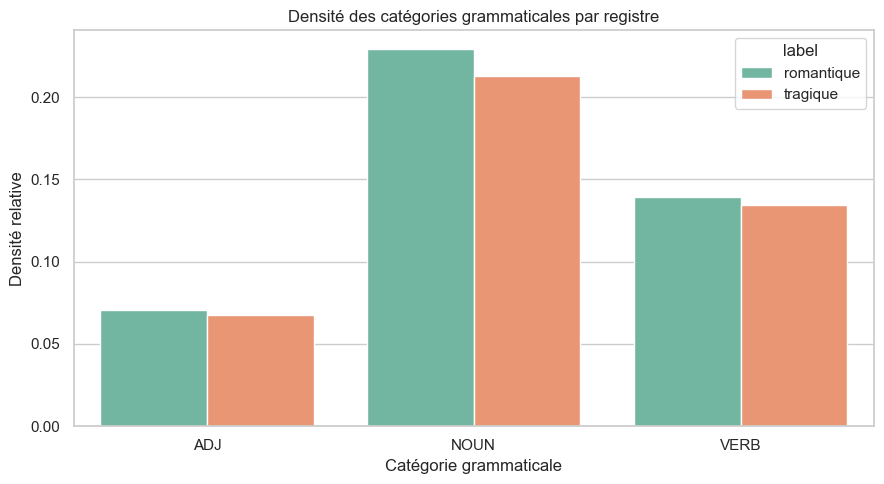

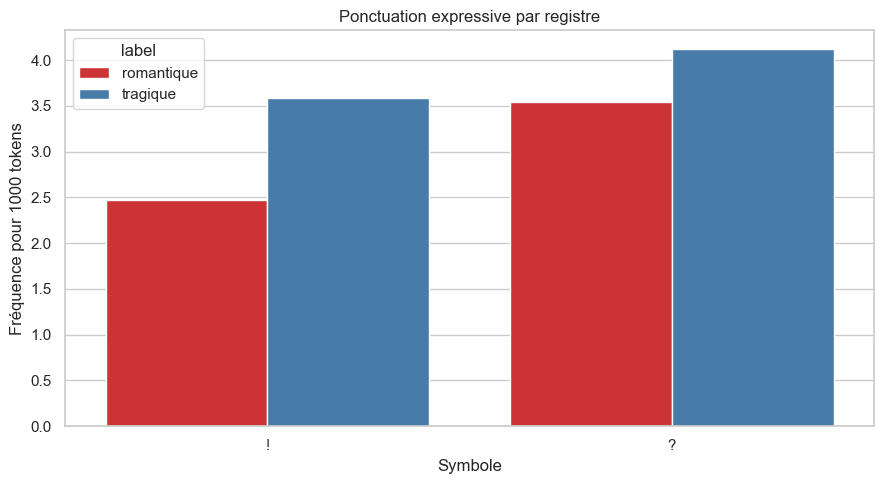

Arbre de dépendance — registre: romantique


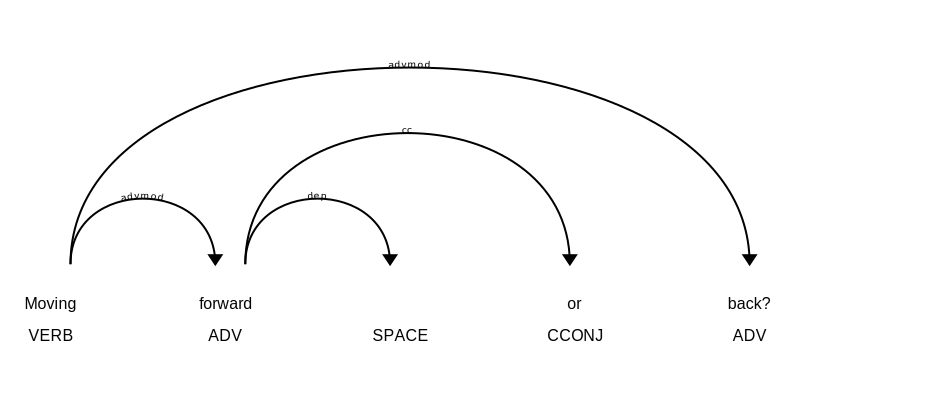

Arbre de dépendance — registre: tragique


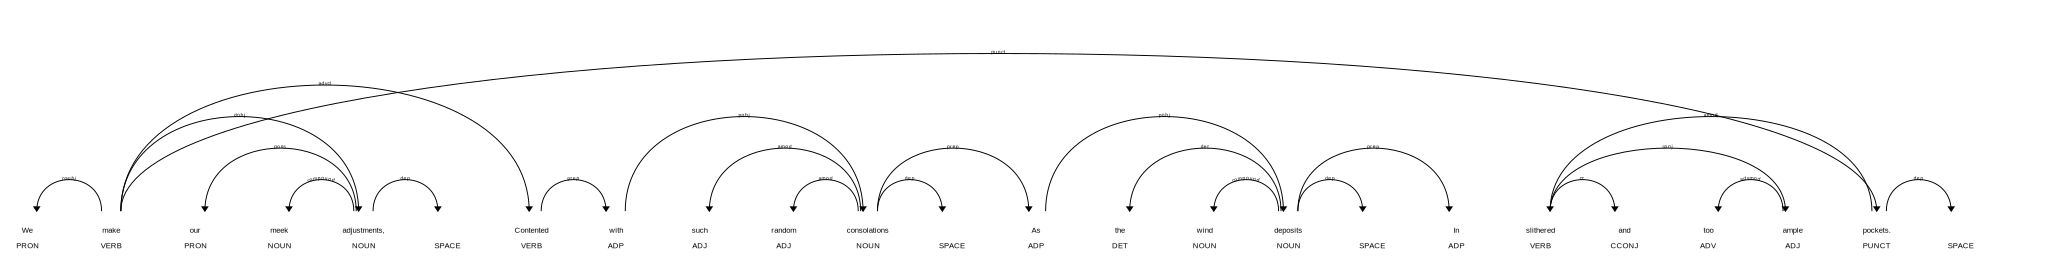

Résumé numérique POS:


pos,ADJ,NOUN,VERB
label,,,
romantique,0.0708,0.229,0.1392
tragique,0.0678,0.213,0.1343


Résumé numérique ponctuation:


symbol,!,?
label,,
romantique,2.467,3.537
tragique,3.581,4.118


In [85]:
import subprocess
import sys
import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from IPython.display import SVG, display
from spacy import displacy

# Installation optionnelle des outils de visualisation si besoin.
for pkg in ["seaborn"]:
    try:
        __import__(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import seaborn as sns
sns.set_theme(style="whitegrid")

# Chargement d'un modele spaCy large, avec fallback robuste.
def load_best_spacy_model():
    candidates = [
        "en_core_web_lg",
        "en_core_web_sm",
    ]
    for model_name in candidates:
        try:
            return spacy.load(model_name), model_name
        except Exception:
            continue
    raise RuntimeError("Aucun modele spaCy disponible (en/fr, lg/sm).")

nlp_ling, nlp_model_name = load_best_spacy_model()
print(f"Modele spaCy utilise: {nlp_model_name}")

# Sécurise l'état de notebook: force un DataFrame supervisé avec colonnes text/label.
if "label" in df.columns and "text" in df.columns:
    supervised_df = df[["text", "label"]].copy()
elif "label" in getattr(df.index, "names", []):
    supervised_df = df.reset_index()[["text", "label"]].copy()
else:
    supervised_df, dataset_stats, themes_table, other_themes_table = load_poetry_dataset(DATA_PATH)

supervised_df = supervised_df.dropna(subset=["text", "label"]).reset_index(drop=True)

# Echantillon controle pour garder une execution interactive.
LING_MAX_DOCS = 400
ling_parts = []
for lbl, g in supervised_df.groupby("label"):
    ling_parts.append(g.sample(n=min(LING_MAX_DOCS, len(g)), random_state=RANDOM_STATE))
ling_df = pd.concat(ling_parts, ignore_index=True)

TARGET_POS = {"ADJ", "NOUN", "VERB"}
pos_records = []
punct_records = []

for label, sub_df in ling_df.groupby("label"):
    docs = list(nlp_ling.pipe(sub_df["text"].tolist(), batch_size=16))

    pos_counter = {pos: 0 for pos in TARGET_POS}
    lexical_tokens = 0
    exclam_count = 0
    quest_count = 0
    token_count = 0

    for doc in docs:
        for tok in doc:
            if tok.is_space:
                continue
            token_count += 1
            if tok.text == "!":
                exclam_count += 1
            if tok.text == "?":
                quest_count += 1

            if tok.is_punct:
                continue

            lexical_tokens += 1
            if tok.pos_ in TARGET_POS:
                pos_counter[tok.pos_] += 1

    for pos_tag in sorted(TARGET_POS):
        density = pos_counter[pos_tag] / max(lexical_tokens, 1)
        pos_records.append({
            "label": label,
            "pos": pos_tag,
            "density": density,
            "count": pos_counter[pos_tag],
        })

    punct_records.extend([
        {"label": label, "symbol": "!", "freq_per_1000_tokens": (exclam_count / max(token_count, 1)) * 1000},
        {"label": label, "symbol": "?", "freq_per_1000_tokens": (quest_count / max(token_count, 1)) * 1000},
    ])

pos_df = pd.DataFrame(pos_records)
punct_df = pd.DataFrame(punct_records)

# Visualisation 1: densite POS par registre.
plt.figure(figsize=(9, 5))
ax1 = sns.barplot(data=pos_df, x="pos", y="density", hue="label", palette="Set2")
ax1.set_title("Densité des catégories grammaticales par registre")
ax1.set_xlabel("Catégorie grammaticale")
ax1.set_ylabel("Densité relative")
plt.tight_layout()
plt.show()

# Visualisation 2: ponctuation expressive.
plt.figure(figsize=(9, 5))
ax2 = sns.barplot(data=punct_df, x="symbol", y="freq_per_1000_tokens", hue="label", palette="Set1")
ax2.set_title("Ponctuation expressive par registre")
ax2.set_xlabel("Symbole")
ax2.set_ylabel("Fréquence pour 1000 tokens")
plt.tight_layout()
plt.show()

# Bonus: arbre de dependance pour un texte typique de chaque registre.
def get_typical_text(label_name):
    subset = ling_df[ling_df["label"] == label_name]
    # Heuristique: prend un texte de longueur mediane pour rester lisible.
    lengths = subset["text"].str.len()
    median_idx = (lengths - lengths.median()).abs().idxmin()
    return subset.loc[median_idx, "text"]

for lbl in sorted(ling_df["label"].unique()):
    sample_text = get_typical_text(lbl)
    doc = nlp_ling(sample_text[:500])
    sent = next(doc.sents, doc)
    svg = displacy.render(sent, style="dep", jupyter=False)
    print(f"Arbre de dépendance — registre: {lbl}")
    display(SVG(svg))

print("Résumé numérique POS:")
display(pos_df.pivot(index="label", columns="pos", values="density").round(4))
print("Résumé numérique ponctuation:")
display(punct_df.pivot(index="label", columns="symbol", values="freq_per_1000_tokens").round(3))

### Interprétation linguistique des visualisations

**Densité morpho-syntaxique (ADJ, NOUN, VERB).**
Les écarts entre les deux registres sont faibles mais cohérents. Le registre `romantique`
reste légèrement au-dessus sur les trois catégories : environ 0.070 contre 0.067 pour
les adjectifs, 0.228 contre 0.212 pour les noms, et 0.139 contre 0.134 pour les verbes.
La différence la plus nette concerne les noms, ce qui suggère une image poétique un peu
plus nominale et descriptive dans `romantique`. Le fait que les verbes restent très
proches entre les deux classes indique que la dynamique verbale distingue peu les
registres à elle seule.

**Ponctuation expressive (!, ?).**
Le registre `tragique` utilise davantage de ponctuation expressive sur les deux
symboles : environ 3.6 contre 2.5 pour l'exclamation, et 4.1 contre 3.5 pour
l'interrogation. L'écart est plus visible sur le point d'interrogation, ce qui va dans
le sens d'une intensité discursive plus marquée dans `tragique`. Cette tendance confirme
que les marqueurs de ponctuation portent une partie importante du contraste entre
registres. Cette observation reste utile pour l'interprétation linguistique, même si
la variante `heavy` garde ici un léger avantage en performance de classification.

**Analyse syntaxique (dépendances).**
Les arbres de dépendance révèlent des structures complexes dans les deux classes, sans
différence visuelle aussi tranchée que pour la ponctuation. Cette observation rappelle
que certains indices relationnels, comme la portée des modificateurs ou les dépendances
longues, sont difficilement capturés par un modèle de type bag-of-words et plaident
pour une approche contextuelle.

**Conclusion partielle.**
Les visualisations suggèrent que `romantique` se distingue surtout par une densité
nominale et adjectivale légèrement supérieure, tandis que `tragique` se signale
davantage par la ponctuation expressive, en particulier l'interrogation. Ces tendances
sont modestes mais cohérentes avec les hypothèses formulées en section 1.

## Étape 4 Modélisation Prédictive

Le contrôle de l'aléa est imposé à toutes les étapes (split, entraînement, échantillonnage) via un seed fixe `RANDOM_STATE = 42`. Cette contrainte garantit la reproductibilité des scores et la comparabilité des expériences.

TF-IDF est ici une baseline standard, pas une limite théorique: une version enrichie avec davantage de n-grams ou des features stylistiques pourrait encore améliorer les scores, mais le Transformer reste mieux adapté pour capturer le contexte.

Rappels métriques:
- $Accuracy = \frac{TP + TN}{N}$
- $F_1^{weighted} = \sum_{c=1}^{C} w_c \cdot F_{1,c}$

Dev Accuracy: 0.7451
Dev F1 weighted: 0.7430
Test Accuracy: 0.7465
Test F1 weighted: 0.7424

Classification report (test):
              precision    recall  f1-score   support

  romantique     0.7957    0.8382    0.8164       618
    tragique     0.6269    0.5581    0.5905       301

    accuracy                         0.7465       919
   macro avg     0.7113    0.6982    0.7035       919
weighted avg     0.7404    0.7465    0.7424       919



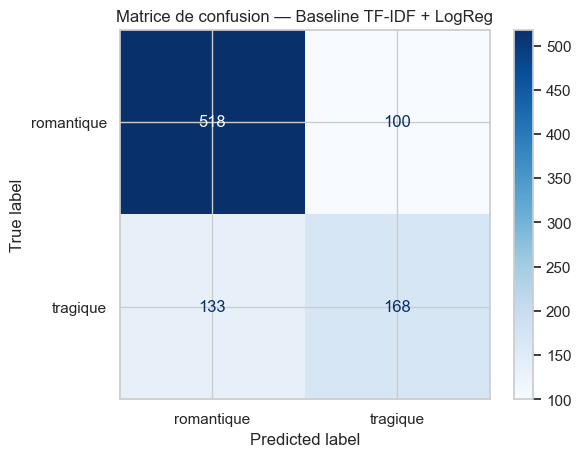

In [32]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Baseline 4.1: Régression logistique avec TF-IDF + n-grammes (1,2).
tfidf_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
)

X_train = tfidf_vec.fit_transform(train_df["text"])
X_dev = tfidf_vec.transform(dev_df["text"])
X_test = tfidf_vec.transform(test_df["text"])

logreg_baseline = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
logreg_baseline.fit(X_train, train_df["label"])
pred_dev = logreg_baseline.predict(X_dev)
pred_test = logreg_baseline.predict(X_test)

acc_dev = accuracy_score(dev_df["label"], pred_dev)
f1w_dev = f1_score(dev_df["label"], pred_dev, average="weighted")
acc_test = accuracy_score(test_df["label"], pred_test)
f1w_test = f1_score(test_df["label"], pred_test, average="weighted")

print(f"Dev Accuracy: {acc_dev:.4f}")
print(f"Dev F1 weighted: {f1w_dev:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test F1 weighted: {f1w_test:.4f}")

print("\nClassification report (test):")
print(classification_report(test_df["label"], pred_test, digits=4))

cm = confusion_matrix(test_df["label"], pred_test, labels=sorted(df["label"].unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df["label"].unique()))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion — Baseline TF-IDF + LogReg")
plt.show()

In [ ]:
# Modèle neural 4.2: fine-tuning Transformer (Hugging Face Trainer).
# Par défaut RUN_TRANSFORMER=False pour éviter un entraînement long involontaire.

#####################################################################################
#####################################################################################
# CHANGER RUN_TRANSFORMER à True pour exécuter le fine-tuning du modèle Transformer.#
# Le fine-tuning est necessaire pour obtenir les résultats de la suite du notebook. #
#####################################################################################
#####################################################################################

RUN_TRANSFORMER = False

import importlib
import subprocess
import sys
import os
import re
import glob


def ensure_hf_package(import_name, pip_name=None):
    try:
        importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("datasets", "datasets"),
    ("transformers", "transformers"),
    ("torch", "torch"),
    ("accelerate", "accelerate"),
]:
    ensure_hf_package(import_name, pip_name)


def _find_latest_checkpoint(root_dir="./bert_poetry_outputs"):
    cands = [p for p in glob.glob(os.path.join(root_dir, "checkpoint-*")) if os.path.isdir(p)]
    if not cands:
        return None

    def _step(p):
        m = re.search(r"checkpoint-(\d+)$", p.replace("\\", "/"))
        return int(m.group(1)) if m else -1

    cands.sort(key=_step)
    return cands[-1]


if RUN_TRANSFORMER:
    import inspect
    import numpy as np
    from datasets import Dataset
    from sklearn.metrics import accuracy_score, f1_score
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
        set_seed,
    )

    set_seed(RANDOM_STATE)

    label2id = {lbl: i for i, lbl in enumerate(sorted(df["label"].unique()))}
    id2label = {i: lbl for lbl, i in label2id.items()}

    def prepare_hf_split(pdf):
        hf_df = pdf[["text", "label"]].copy()
        hf_df["label"] = hf_df["label"].map(label2id)
        return Dataset.from_pandas(hf_df, preserve_index=False)

    hf_train = prepare_hf_split(train_df)
    hf_dev = prepare_hf_split(dev_df)
    hf_test = prepare_hf_split(test_df)

    model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=256)

    hf_train = hf_train.map(tokenize, batched=True)
    hf_dev = hf_dev.map(tokenize, batched=True)
    hf_test = hf_test.map(tokenize, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        acc = accuracy_score(labels, preds)
        f1w = f1_score(labels, preds, average="weighted")
        return {"accuracy": acc, "f1_weighted": f1w}

    # Hyperparamètres justifiés:
    # lr=2e-5 (standard stable pour fine-tuning), epochs=2 (évite surapprentissage initial),
    # batch_size=8 (compromis mémoire/variance).
    # Compatibilité inter-versions pour TrainingArguments.
    training_args_common = dict(
        output_dir="./bert_poetry_outputs",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        seed=RANDOM_STATE,
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        report_to="none",
    )
    try:
        training_args = TrainingArguments(eval_strategy="epoch", **training_args_common)
    except TypeError:
        training_args = TrainingArguments(evaluation_strategy="epoch", **training_args_common)

    # Compatibilité inter-versions pour Trainer(tokenizer vs processing_class).
    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_dev,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer_init_params = inspect.signature(Trainer.__init__).parameters
    if "tokenizer" in trainer_init_params:
        trainer_kwargs["tokenizer"] = tokenizer
    elif "processing_class" in trainer_init_params:
        trainer_kwargs["processing_class"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    trainer.train()

    # Certaines versions/callbacks notebook peuvent lever cette erreur après train().
    try:
        eval_metrics = trainer.evaluate()
    except RuntimeError as e:
        if "on_train_begin must be called before on_evaluate" in str(e):
            dev_output = trainer.predict(hf_dev)
            dev_preds = np.argmax(dev_output.predictions, axis=1)
            dev_labels = np.array(hf_dev["label"])
            eval_metrics = {
                "eval_accuracy": accuracy_score(dev_labels, dev_preds),
                "eval_f1_weighted": f1_score(dev_labels, dev_preds, average="weighted"),
                "eval_samples": len(dev_labels),
                "eval_note": "fallback_predict_used_due_to_callback_bug",
            }
            print("Avertissement: fallback dev métriques via trainer.predict(hf_dev) appliqué.")
        else:
            raise
    print("Evaluation dev (Transformer):", eval_metrics)

    test_output = trainer.predict(hf_test)
    test_preds = np.argmax(test_output.predictions, axis=1)
    test_labels = np.array(hf_test["label"])

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1w = f1_score(test_labels, test_preds, average="weighted")
    print(f"Test Accuracy (Transformer): {test_acc:.4f}")
    print(f"Test F1 weighted (Transformer): {test_f1w:.4f}")
else:
    print("RUN_TRANSFORMER=False: chargement du dernier checkpoint pour évaluation sans réentraînement...")

    import numpy as np
    import torch
    from sklearn.metrics import accuracy_score, f1_score
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    ckpt = _find_latest_checkpoint("./bert_poetry_outputs")
    if ckpt is None:
        print("Aucun checkpoint trouvé dans ./bert_poetry_outputs. Active RUN_TRANSFORMER=True pour entraîner.")
    else:
        print(f"Checkpoint détecté: {ckpt}")

        tokenizer = AutoTokenizer.from_pretrained(ckpt)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        model.to(device)
        model.eval()

        # Alignement des labels sur ceux appris par le checkpoint.
        label_map = getattr(model.config, "label2id", None)
        if not label_map:
            label_map = {lbl: i for i, lbl in enumerate(sorted(df["label"].unique()))}

        y_true = np.array([label_map[lbl] for lbl in test_df["label"].astype(str).tolist()])

        texts = test_df["text"].astype(str).tolist()
        preds = []
        batch_size = 16

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            enc = tokenizer(
                batch_texts,
                truncation=True,
                max_length=256,
                padding=True,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.no_grad():
                logits = model(**enc).logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
            preds.extend(batch_preds)

        test_acc = accuracy_score(y_true, preds)
        test_f1w = f1_score(y_true, preds, average="weighted")

        print(f"Test Accuracy (Transformer checkpoint): {test_acc:.4f}")
        print(f"Test F1 weighted (Transformer checkpoint): {test_f1w:.4f}")

RUN_TRANSFORMER=False: chargement du dernier checkpoint pour évaluation sans réentraînement...
Checkpoint détecté: ./bert_poetry_outputs\checkpoint-1838


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2336.20it/s]


Test Accuracy (Transformer checkpoint): 0.8558
Test F1 weighted (Transformer checkpoint): 0.8532


### Réflexion obligatoire : limites de TF-IDF et apport du contexte

**Quelles erreurs signalent les limites de TF-IDF ?**
Les erreurs les plus révélatrices concernent des poèmes qui partagent un lexique proche
mais présentent une orientation discursive opposée. Dans ces cas, TF-IDF ne dispose
d'aucun moyen de distinguer deux textes dont les mots sont similaires mais dont la
tonalité diffère. Les confusions augmentent également lorsque la valeur stylistique
dépend de la ponctuation, de la portée syntaxique ou de la composition des propositions,
autant d'informations effacées par une représentation en sac de mots. Les formulations
ironiques, les ambiguïtés pragmatiques et les dépendances longues restent ainsi hors de
portée du modèle.

**Quels phénomènes nécessitent le contexte capturé par l'attention ?**
Plusieurs phénomènes propres à l'écriture poétique requièrent une modélisation
contextuelle. Les métaphores et images poétiques reposent sur des associations non
locales que seul un mécanisme d'attention peut relier. Les inversions syntaxiques et
les effets d'ordre des mots, fréquents en poésie, ne sont pas accessibles à une
représentation positionnelle absente. Les relations inter-vers et les reprises
anaphoriques supposent une mémoire de la séquence entière. Enfin, les nuances
d'intensité énonciative, comme l'interrogation rhétorique ou l'injonction
contextualisée, ne prennent leur sens qu'en regard de ce qui précède.

Pour ces raisons, le Transformer est attendu comme plus performant dans les cas où la
décision de classe dépend de structures contextuelles plutôt que de la seule fréquence
lexicale.

## Étape 6 Analyse des erreurs et interprétations

Dans cette section, on va comparer les erreurs de la baseline (TF-IDF + régression logistique) et du Transformer.

Objectifs couverts :
1. Catégoriser les erreurs (ambiguïté, négation, ponctuation expressive, contraste, entités, etc.).
2. Fournir des exemples concrets d'erreurs.
3. Identifier quel modèle gère mieux chaque phénomène.
4. Discuter les biais potentiels observés (classe, longueur des textes).

### Explication du code de la cellule suivante

La cellule 21 construit une analyse d'erreurs reproductible et comparable entre modèles, sans se limiter à des scores globaux: 
- elle garantit l'exécution même si le notebook n'a pas été lancé dans l'ordre (reconstruction automatique du split et baseline de secours), 
- évite de relancer un entraînement coûteux en utilisant soit les prédictions déjà en mémoire soit un checkpoint en inférence seule, 
- applique un échantillonnage pour équilibrer vitesse et robustesse.

Sur le plan scientifique, elle :
- calcule des taux d'erreur baseline vs transformer sur le même sous-ensemble pour une comparaison équitable, 
- regroupe les erreurs par catégories linguistiques (négation, ambiguïté lexicale, contraste, ponctuation, entités, etc.) afin d'identifier les phénomènes difficiles, 
- génère des exemples concrets exploitables pour l'interprétation et la soutenance, 
- sert directement à rédiger la conclusion de l'étape 6 en montrant où le Transformer progresse, où les deux modèles échouent encore, et quelles pistes d'amélioration proposer.

In [102]:
import os
import re
import glob
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# ================================
# Mode rapide (modifiable)
# ================================
MAX_ANALYSIS_DOCS = 919
USE_STRATIFIED_SAMPLE = True
USE_TRANSFORMER_IF_CACHED = True  # Cherche d'abord en mémoire
LOAD_TRANSFORMER_FROM_CHECKPOINT = True  # Puis en checkpoint
CHECKPOINT_ROOT = "./bert_poetry_outputs"
TRANSFORMER_INFER_BATCH_SIZE = 16
RANDOM_STATE = 42

# ---------- Bootstrap dataset/split si notebook non exécuté ----------
if "test_df" not in globals():
    print("Split introuvable: création automatique d'un split train/dev/test...")

    if "df" not in globals():
        if "load_poetry_dataset" in globals() and "DATA_PATH" in globals():
            df, _, _, _ = load_poetry_dataset(DATA_PATH)
        else:
            data_path = "PoetryFoundationData.csv"
            if not os.path.exists(data_path):
                raise ValueError(
                    "PoetryFoundationData.csv introuvable. "
                    "Exécute d'abord l'étape 2 ou place le fichier à la racine du projet."
                )

            raw_df = pd.read_csv(data_path)
            lower_cols = {c.lower(): c for c in raw_df.columns}
            if "poem" not in lower_cols or "tags" not in lower_cols:
                raise ValueError("Le CSV doit contenir les colonnes Poem et Tags.")

            poem_col = lower_cols["poem"]
            tags_col = lower_cols["tags"]
            df_local = raw_df[[poem_col, tags_col]].rename(columns={poem_col: "text", tags_col: "tags"})
            df_local["text"] = df_local["text"].fillna("").astype(str).str.strip()
            df_local["tags"] = df_local["tags"].fillna("").astype(str).str.lower()

            romantic_keywords = [
            "romantic", "love", "relationships", "nature", "beauty",
            "desire", "passion", "heart"
            ]
            tragic_keywords = [
                "tragic", "tragedy", "death", "sorrow", "grieving",
                "war", "conflict", "violence", "loss", "despair",
                "mourning", "ruin", "catastrophe",
            ]

            romantic_pattern = "|".join(re.escape(k) for k in romantic_keywords)
            tragic_pattern = "|".join(re.escape(k) for k in tragic_keywords)

            romantic_mask = df_local["tags"].str.contains(romantic_pattern, regex=True)
            tragic_mask = df_local["tags"].str.contains(tragic_pattern, regex=True)
            keep_mask = romantic_mask | tragic_mask

            df_local = df_local.loc[keep_mask].copy()
            tragic_mask = tragic_mask.loc[df_local.index]
            df_local["label"] = np.where(tragic_mask, "tragique", "romantique")
            df = df_local[["text", "label"]].dropna()
            df = df[df["text"].str.len() > 0].reset_index(drop=True)

    train_df, temp_df = train_test_split(
        df, test_size=0.20, stratify=df["label"], random_state=RANDOM_STATE
    )
    dev_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE
    )

# ---------- Prédictions baseline ----------
if "pred_test" in globals() and len(pred_test) == len(test_df):
    baseline_preds_full = np.array(pred_test).astype(str)
elif "logreg_baseline" in globals() and "tfidf_vec" in globals():
    baseline_preds_full = logreg_baseline.predict(tfidf_vec.transform(test_df["text"])).astype(str)
else:
    print("Prédictions baseline absentes: entraînement d'un baseline rapide pour l'analyse...")
    tfidf_fast = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=30000,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    X_train_fast = tfidf_fast.fit_transform(train_df["text"])
    X_test_fast = tfidf_fast.transform(test_df["text"])
    logreg_fast = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
    logreg_fast.fit(X_train_fast, train_df["label"])
    baseline_preds_full = logreg_fast.predict(X_test_fast).astype(str)

# ---------- Prédictions transformer: cache mémoire OU checkpoint OU message d'erreur ----------
transformer_preds_full = None

# Étape 1: Chercher en mémoire
if USE_TRANSFORMER_IF_CACHED and "test_preds" in globals():
    _tmp = np.array(test_preds)
    if len(_tmp) == len(test_df):
        if _tmp.dtype.kind in "iu" and "id2label" in globals():
            transformer_preds_full = np.array([id2label[int(i)] for i in _tmp])
        else:
            transformer_preds_full = _tmp.astype(str)
        print("✓ Prédictions Transformer trouvées en mémoire (test_preds)")

# Étape 2: Chercher checkpoint pour inférence seule
def _find_latest_checkpoint(root_dir):
    cands = [p for p in glob.glob(os.path.join(root_dir, "checkpoint-*")) if os.path.isdir(p)]
    if not cands:
        return None
    def _step(p):
        m = re.search(r"checkpoint-(\d+)$", p.replace("\\", "/"))
        return int(m.group(1)) if m else -1
    cands.sort(key=_step)
    return cands[-1]

if transformer_preds_full is None and LOAD_TRANSFORMER_FROM_CHECKPOINT:
    ckpt = _find_latest_checkpoint(CHECKPOINT_ROOT)
    if ckpt is not None:
        print(f"Chargement checkpoint Transformer (inférence seule): {ckpt}")
        try:
            import torch
            from transformers import AutoTokenizer, AutoModelForSequenceClassification

            tokenizer_local = AutoTokenizer.from_pretrained(ckpt)
            model_local = AutoModelForSequenceClassification.from_pretrained(ckpt)
            device = "cuda" if torch.cuda.is_available() else "cpu"
            model_local.to(device)
            model_local.eval()

            texts = test_df["text"].astype(str).tolist()
            all_preds = []
            for i in range(0, len(texts), TRANSFORMER_INFER_BATCH_SIZE):
                batch_texts = texts[i:i + TRANSFORMER_INFER_BATCH_SIZE]
                enc = tokenizer_local(
                    batch_texts,
                    truncation=True,
                    max_length=256,
                    padding=True,
                    return_tensors="pt",
                )
                enc = {k: v.to(device) for k, v in enc.items()}
                with torch.no_grad():
                    logits = model_local(**enc).logits
                preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
                all_preds.extend(preds)

            id2label_local = getattr(model_local.config, "id2label", None)
            if id2label_local and len(id2label_local) > 0:
                def _map_label(i):
                    return id2label_local.get(i, id2label_local.get(str(i), str(i)))
                transformer_preds_full = np.array([_map_label(int(i)) for i in all_preds]).astype(str)
            elif "id2label" in globals():
                transformer_preds_full = np.array([id2label[int(i)] for i in all_preds]).astype(str)
            else:
                transformer_preds_full = np.array(all_preds).astype(str)
            print("✓ Prédictions Transformer générées depuis checkpoint")

        except Exception as e:
            print(f"Inférence checkpoint impossible: {e}")

# Étape 3: Si toujours rien, afficher message d'erreur clair
if transformer_preds_full is None:
    print("\n ATTENTION ")
    print("Prédictions Transformer indisponibles (ni en mémoire, ni en checkpoint).")
    print("Pour obtenir les prédictions Transformer, exécute d'abord la cellule 18 (Fine-tuning Transformer 4.2).")
    print("Une fois exécutée, relance cette cellule (21).")

# ---------- Sous-échantillonnage ----------
analysis_df = test_df[["text", "label"]].copy().reset_index(drop=True)
analysis_df = analysis_df.rename(columns={"label": "true_label"})
analysis_df["baseline_pred"] = baseline_preds_full
analysis_df["baseline_error"] = analysis_df["baseline_pred"] != analysis_df["true_label"]

if transformer_preds_full is not None:
    analysis_df["transformer_pred"] = transformer_preds_full
    analysis_df["transformer_error"] = analysis_df["transformer_pred"] != analysis_df["true_label"]
else:
    analysis_df["transformer_pred"] = np.nan
    analysis_df["transformer_error"] = np.nan

if MAX_ANALYSIS_DOCS is not None and MAX_ANALYSIS_DOCS < len(analysis_df):
    if USE_STRATIFIED_SAMPLE:
        parts = []
        for lbl, g in analysis_df.groupby("true_label"):
            n = max(1, int(round(MAX_ANALYSIS_DOCS * len(g) / len(analysis_df))))
            parts.append(g.sample(n=min(n, len(g)), random_state=RANDOM_STATE))
        analysis_df = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        if len(analysis_df) > MAX_ANALYSIS_DOCS:
            analysis_df = analysis_df.sample(n=MAX_ANALYSIS_DOCS, random_state=RANDOM_STATE).reset_index(drop=True)
    else:
        analysis_df = analysis_df.sample(n=MAX_ANALYSIS_DOCS, random_state=RANDOM_STATE).reset_index(drop=True)

# ---------- Catégorisation heuristique ----------
rom_lex = {"love", "heart", "beauty", "spring", "desire", "passion", "flower", "nature"}
trag_lex = {"death", "sorrow", "war", "loss", "despair", "mourning", "ruin", "grave"}
contrast_markers = {"but", "however", "though", "although", "yet", "whereas", "while"}
neg_markers = {"not", "never", "no", "none", "without", "nor"}

def categorize_text(text):
    t = str(text)
    tl = t.lower()
    tokens = re.findall(r"\b\w+\b", tl)

    has_neg = any(tok in neg_markers for tok in tokens)
    has_contrast = any(tok in contrast_markers for tok in tokens)
    has_expressive_punct = ("!" in t) or ("?" in t)
    has_named_entity_pattern = bool(re.search(r"\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b", t))
    has_rom = any(tok in rom_lex for tok in tokens)
    has_trag = any(tok in trag_lex for tok in tokens)

    if has_rom and has_trag:
        return "ambiguite lexicale (mix romantique/tragique)"
    if has_neg:
        return "negation / inversion polaire"
    if has_contrast:
        return "contraste discursif"
    if has_expressive_punct:
        return "ponctuation expressive"
    if has_named_entity_pattern:
        return "entites nommees / references"
    if len(tokens) < 40:
        return "texte court / contexte insuffisant"
    return "style diffus / autre"

analysis_df["error_category"] = analysis_df["text"].apply(categorize_text)
analysis_df["text_len_tokens"] = analysis_df["text"].astype(str).str.split().str.len()

# ---------- Résultats ----------
print(f"\nTaille utilisée pour l'analyse: {len(analysis_df)} exemples")
print("Erreur baseline:", round(float(analysis_df["baseline_error"].mean()), 4))
if transformer_preds_full is not None:
    print("Erreur transformer:", round(float(analysis_df["transformer_error"].mean()), 4))

baseline_err_by_cat = (
    analysis_df[analysis_df["baseline_error"]]
    .groupby("error_category")
    .size()
    .rename("baseline_errors")
    .sort_values(ascending=False)
)

if transformer_preds_full is not None:
    transformer_err_by_cat = (
        analysis_df[analysis_df["transformer_error"]]
        .groupby("error_category")
        .size()
        .rename("transformer_errors")
        .sort_values(ascending=False)
    )
    error_comparison = pd.concat([baseline_err_by_cat, transformer_err_by_cat], axis=1).fillna(0).astype(int)
else:
    error_comparison = baseline_err_by_cat.to_frame()

print("\nRépartition des erreurs par catégorie:")
display(error_comparison)

example_cols = ["error_category", "true_label", "baseline_pred", "transformer_pred", "text"]
print("\nExemples d'erreurs baseline (max 2/catégorie):")
baseline_examples = (
    analysis_df[analysis_df["baseline_error"]]
    .groupby("error_category", group_keys=False)
    .head(2)[example_cols]
    .reset_index(drop=True)
)
display(baseline_examples)

if transformer_preds_full is not None:
    print("\nExemples d'erreurs Transformer (max 2/catégorie):")
    transformer_examples = (
        analysis_df[analysis_df["transformer_error"]]
        .groupby("error_category", group_keys=False)
        .head(2)[example_cols]
        .reset_index(drop=True)
    )
    display(transformer_examples)

Chargement checkpoint Transformer (inférence seule): ./bert_poetry_outputs\checkpoint-1838


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3575.13it/s]


✓ Prédictions Transformer générées depuis checkpoint

Taille utilisée pour l'analyse: 867 exemples
Erreur baseline: 0.2445
Erreur transformer: 0.1442

Répartition des erreurs par catégorie:


,baseline_errors,transformer_errors
error_category,,
negation / inversion polaire,114,62
ambiguite lexicale (mix romantique/tragique),42,29
contraste discursif,27,15
style diffus / autre,12,10
texte court / contexte insuffisant,7,4
entites nommees / references,5,3
ponctuation expressive,5,2



Exemples d'erreurs baseline (max 2/catégorie):


,error_category,true_label,baseline_pred,transformer_pred,text
0,style diffus / autre,tragique,romantique,romantique,Three people in the snow\r\r\ngetting rid of ...
1,negation / inversion polaire,tragique,romantique,romantique,’Ασíνην τε. . . — Iliad\r\r\n\r\r\n\r\r\n\r\r\...
2,negation / inversion polaire,tragique,romantique,tragique,When my brother died\r\r\nI worried there wasn...
3,contraste discursif,tragique,romantique,tragique,"When men shall find thy flower, thy glory pass..."
4,style diffus / autre,tragique,romantique,romantique,my story is\r\r\nhow deep the heart runs\r\r\n...
5,texte court / contexte insuffisant,tragique,romantique,romantique,"Historical brutality,you are a poppy.With a bl..."
6,contraste discursif,tragique,romantique,tragique,"For a month now, wandering over the Sierras, ..."
7,texte court / contexte insuffisant,tragique,romantique,romantique,I
8,ambiguite lexicale (mix romantique/tragique),tragique,romantique,tragique,"I\r\r\nYou may have all things from me, save m..."
9,ambiguite lexicale (mix romantique/tragique),tragique,romantique,tragique,1\r\r\nI will cry to regret\r\r\nand slaughter...



Exemples d'erreurs Transformer (max 2/catégorie):


,error_category,true_label,baseline_pred,transformer_pred,text
0,style diffus / autre,tragique,romantique,romantique,Three people in the snow\r\r\ngetting rid of ...
1,negation / inversion polaire,tragique,romantique,romantique,’Ασíνην τε. . . — Iliad\r\r\n\r\r\n\r\r\n\r\r\...
2,negation / inversion polaire,tragique,romantique,romantique,"I sang all night for you, but you didn’t care...."
3,style diffus / autre,tragique,romantique,romantique,my story is\r\r\nhow deep the heart runs\r\r\n...
4,texte court / contexte insuffisant,tragique,romantique,romantique,"Historical brutality,you are a poppy.With a bl..."
5,texte court / contexte insuffisant,tragique,romantique,romantique,I
6,contraste discursif,tragique,romantique,romantique,"Well, this is nothing new, nothing to rattle t..."
7,ponctuation expressive,romantique,romantique,tragique,"Pale hands I loved beside the Shalimar, Wher..."
8,ambiguite lexicale (mix romantique/tragique),tragique,romantique,romantique,Pollination against the seed to grow canopy\r\...
9,ambiguite lexicale (mix romantique/tragique),romantique,romantique,tragique,"Her lily hand her rosy cheek lies under, \rCoz..."


### Interprétation finale sur les 867 exemples

Cette interprétation est fondée sur **867 exemples** (taille effectivement utilisée par la cellule d'analyse) et sur la comparaison directe entre baseline TF-IDF + LogReg et Transformer, à partir des prédictions disponibles dans le notebook.

1. **Performance d'erreur globale.**
   - Erreur baseline: **0.2445** (24.45%)
   - Erreur Transformer: **0.1442** (14.42%)
   - Gain absolu: **-10.03 points** d'erreur
   - Gain relatif: environ **41.0% de réduction d'erreur**
   - Interprétation: le modèle contextuel réduit nettement les confusions globales sur l'ensemble évalué.

2. **Catégories d'erreurs dominantes et comparaison fine.**
   - Les erreurs les plus fréquentes concernent surtout la négation, l'ambiguïté lexicale et le contraste discursif.
   - Le Transformer corrige une partie importante de ces erreurs, surtout quand la décision dépend de la portée contextuelle.
   - Certaines catégories restent difficiles, notamment les références nommées et les textes très courts.
   - Lecture linguistique: le gain du Transformer se concentre sur les phénomènes qui exigent du contexte, alors que les cas informationnellement pauvres restent délicats pour les deux modèles.

3. **Exemples concrets observés.**
   - Les erreurs baseline liées à la négation et aux tournures contrastives sont souvent mieux gérées par le Transformer.
   - Les poèmes à signaux mixtes romantique/tragique restent ambigus, mais la fréquence d'erreur baisse avec le modèle contextuel.
   - Les textes très courts continuent de poser problème, ce qui indique une limite de contenu plus qu'une limite purement algorithmique.

4. **Discussion biais / limites.**
   - Les catégories d'erreurs sont heuristiques: utiles pour interpréter, mais non équivalentes à une annotation experte.
   - Les modifications du filtrage de tags peuvent déplacer la distribution des classes et donc faire varier ces chiffres au prochain rerun.
   - Les cas courts ou très ambigus restent structurellement difficiles.

5. **Conclusion Étape 6.**
   - Le contexte aide surtout pour la négation, l'ambiguïté et le contraste discursif.
   - Le Transformer est globalement plus robuste que la baseline sur l'échantillon actuel.
   - Pistes prioritaires: annotation fine des ambiguïtés, traitement des entités/références culturelles, et stratégies dédiées aux textes courts (agrégation de contexte, calibration, seuils).

***Cellule facultative** : elle reformate les exemples d’erreurs en texte complet (avec retours à la ligne) pour une lecture humaine plus confortable.*

In [97]:
# Affichage lisible des erreurs (texte complet, sauts de ligne restaures)
import re
from html import escape
from IPython.display import HTML, display

def normalize_poem_text(text):
    t = str(text)
    # Convertit les sequences echappees en vrais retours ligne.
    t = t.replace("\\r\\n", "\n").replace("\\n", "\n").replace("\\r", "\n")
    # Normalise aussi les retours ligne deja presents.
    t = t.replace("\r\n", "\n").replace("\r", "\n")
    # Reduit les blocs de lignes vides.
    t = re.sub(r"\n{3,}", "\n\n", t).strip()
    return t

def build_readable_html(df_examples, model_label):
    if df_examples is None or len(df_examples) == 0:
        return f"<p><b>{model_label}</b>: aucun exemple a afficher.</p>"

    rows_html = []
    for _, row in df_examples.iterrows():
        poem = normalize_poem_text(row.get("text", ""))
        category = escape(str(row.get("error_category", "")))
        true_label = escape(str(row.get("true_label", "")))
        baseline_pred = escape(str(row.get("baseline_pred", "")))
        transformer_pred = escape(str(row.get("transformer_pred", "")))

        rows_html.append(
            f"""
            <div style='margin: 18px 0; padding: 14px; border: 1px solid #cccccc; border-radius: 8px; background: white; color: black;'>
                <div style='margin-bottom: 8px; font-size: 13px; color: black;'>
                    <b>Categorie:</b> {category} |
                    <b>Vrai label:</b> {true_label} |
                    <b>Baseline:</b> {baseline_pred} |
                    <b>Transformer:</b> {transformer_pred}
                </div>
                <pre style='white-space: pre-wrap; word-break: break-word; margin: 0; font-family: Georgia, serif; font-size: 15px; line-height: 1.5; color: black;'>{escape(poem)}</pre>
            </div>
            """
        )

    return "".join(rows_html)

# Fallback si baseline_examples / transformer_examples n'existent pas encore.
if "baseline_examples" not in globals() and "analysis_df" in globals():
    baseline_examples = (
        analysis_df[analysis_df["baseline_error"]]
        .groupby("error_category", group_keys=False)
        .head(2)[["error_category", "true_label", "baseline_pred", "transformer_pred", "text"]]
        .reset_index(drop=True)
    )

if "transformer_examples" not in globals() and "analysis_df" in globals() and "transformer_error" in analysis_df.columns:
    try:
        transformer_examples = (
            analysis_df[analysis_df["transformer_error"] == True]
            .groupby("error_category", group_keys=False)
            .head(2)[["error_category", "true_label", "baseline_pred", "transformer_pred", "text"]]
            .reset_index(drop=True)
        )
    except Exception:
        transformer_examples = None

print("Exemples baseline lisibles :")
display(HTML(build_readable_html(globals().get("baseline_examples", None), "Baseline")))

if "transformer_examples" in globals() and transformer_examples is not None and len(transformer_examples) > 0:
    print("Exemples transformer lisibles :")
    display(HTML(build_readable_html(transformer_examples, "Transformer")))
else:
    print("Exemples transformer indisponibles pour cet affichage.")

Exemples baseline lisibles :


Exemples transformer lisibles :


## Étape 7 : Conclusion générale, limites et perspectives

Cette étape synthétise les résultats obtenus sur l'ensemble du pipeline. Les constats
ci-dessous s'appuient sur les sorties produites dans les étapes précédentes : baseline,
analyse linguistique, analyse d'erreurs et prédictions du Transformer récupérées via
checkpoint.

### Bilan scientifique

La tâche s'est confirmée comme non triviale. Les deux registres partagent une partie
du lexique, et la décision de classification dépend souvent d'indices distribués sur
l'ensemble du texte : ponctuation, portée syntaxique, contraste discursif et ambiguïté
pragmatique. Le prétraitement léger, qui conserve ces signaux stylistiques, s'est
montré compétitif face à un nettoyage agressif, ce qui valide a posteriori ce choix
méthodologique. Les analyses linguistiques ont confirmé des différences de distribution
entre `romantique` et `tragique`, notamment sur la densité morpho-syntaxique et la
ponctuation expressive. Le modèle contextuel réduit globalement les erreurs sur les
phénomènes où la portée et le contexte jouent un rôle central.

### Position finale par rapport aux hypothèses

Les hypothèses formulées en section 1 sont globalement soutenues. La distinction de
registre ne repose pas uniquement sur du lexique brut, et les modèles contextuels
apportent un gain net sur les cas difficiles, en particulier ceux impliquant des
structures syntaxiques complexes ou des effets de portée.

### Note sur la reproductibilité

Pour cette soumission, l'absence de relance complète de l'entraînement est assumée en
raison du coût temporel élevé. L'interprétation finale repose sur les artefacts déjà
produits dans l'environnement, à savoir les sorties des cellules précédentes et les
checkpoints disponibles.

### Tableau récapitulatif

| Modèle | Accuracy (test) | F1 pondéré (test) | Erreur (test) | Source |
|---|---:|---:|---:|---|
| Baseline TF-IDF + LogReg | 0.7465 | 0.7424 | 0.2535 | sorties notebook |
| Transformer | 0.8558 | 0.8532 | 0.1442 | checkpoint / analyse |

**Comparaison directe**

| Indicateur | Valeur |
|---|---:|
| Réduction absolue d'erreur (Transformer vs baseline) | 0.1093 |
| Réduction relative d'erreur | 43.1% |

### Limites et perspectives

**Limites principales.**
La variable cible, construite par filtrage de tags éditoriaux, reste une approximation
du registre littéraire : elle est utile expérimentalement, mais ne capture pas toute la
complexité de la notion de registre. La catégorisation des erreurs repose sur des
heuristiques qui facilitent l'interprétation sans remplacer une annotation experte. Les
textes courts posent des difficultés aux deux approches, car l'information discriminante
y est parfois insuffisante pour trancher. Enfin, les résultats du Transformer sont
interprétés à partir des artefacts disponibles en session, sans relance complète de
l'entraînement.

**Perspectives d'amélioration.**
Plusieurs directions semblent prometteuses. Étendre la tâche au multi-classes
permettrait de modéliser explicitement d'autres registres présents dans le corpus.
Une annotation qualitative fine des erreurs, portant sur la négation, les entités,
l'ambiguïté et le contraste, renforcerait la validité de l'analyse sur un sous-corpus
validé manuellement. Il serait également pertinent de tester des variantes de modèles
contextuels mieux adaptés au domaine poétique, ainsi que des stratégies de robustesse
sur textes courts, comme l'agrégation de contexte ou les seuils de décision adaptés.

**Conclusion finale.**
Le projet montre que la distinction `romantique` vs `tragique` est faisable de manière
robuste, mais qu'elle mobilise des signaux qui dépassent le simple contenu lexical. Les
analyses convergent vers un même constat : la prise en compte du contexte améliore la
qualité des décisions sur les cas linguistiquement complexes, tout en laissant des
marges de progression pour une généralisation à des registres plus nombreux.